# 🧠 Salesforce Customer Churn Prediction
**EDA + ANN Training Notebook**

Pipeline: Load CSV → EDA → Preprocessing → Train ANN → Evaluate → Save Model

---

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Plotting style
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print(f'TensorFlow version: {tf.__version__}')
print(f'NumPy version: {np.__version__}')
print(f'Pandas version: {pd.__version__}')

TensorFlow version: 2.21.0
NumPy version: 2.4.3
Pandas version: 2.3.3


## 2. Load Dataset

In [2]:
# Load raw data — always work on a copy
df_raw = pd.read_csv('../data/churn.csv')
df = df_raw.copy()

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head(10)

Dataset shape: (10000, 14)
Rows: 10,000 | Columns: 14


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [3]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
# Statistical summary
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 3. Exploratory Data Analysis (EDA)

### 3.1 Check for Missing & Duplicate Values

In [5]:
# Missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

# Duplicates
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values per column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Total missing: 0

Duplicate rows: 0


### 3.2 Target Distribution (Class Imbalance Check)

Target Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Rate: 20.37%


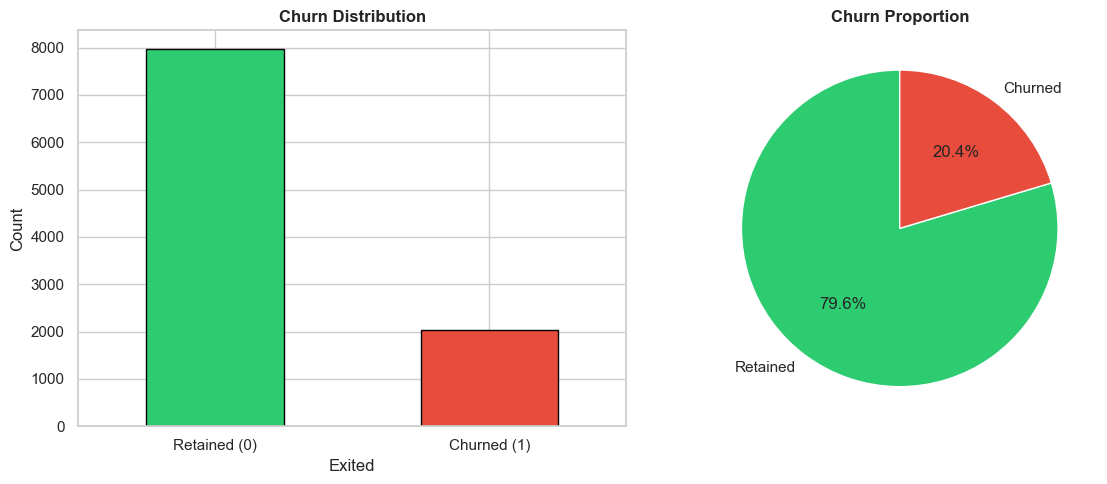

In [6]:
# Target column is 'Exited' (1 = churned, 0 = retained)
target_col = 'Exited'

print('Target Distribution:')
print(df[target_col].value_counts())
print(f'\nChurn Rate: {df[target_col].mean():.2%}')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
colors = ['#2ecc71', '#e74c3c']
df[target_col].value_counts().plot(kind='bar', ax=ax[0], color=colors, edgecolor='black')
ax[0].set_title('Churn Distribution', fontweight='bold')
ax[0].set_xticklabels(['Retained (0)', 'Churned (1)'], rotation=0)
ax[0].set_ylabel('Count')

# Pie chart
df[target_col].value_counts().plot(kind='pie', ax=ax[1], colors=colors,
                                     autopct='%1.1f%%', startangle=90,
                                     labels=['Retained', 'Churned'])
ax[1].set_title('Churn Proportion', fontweight='bold')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 3.3 Feature Distributions

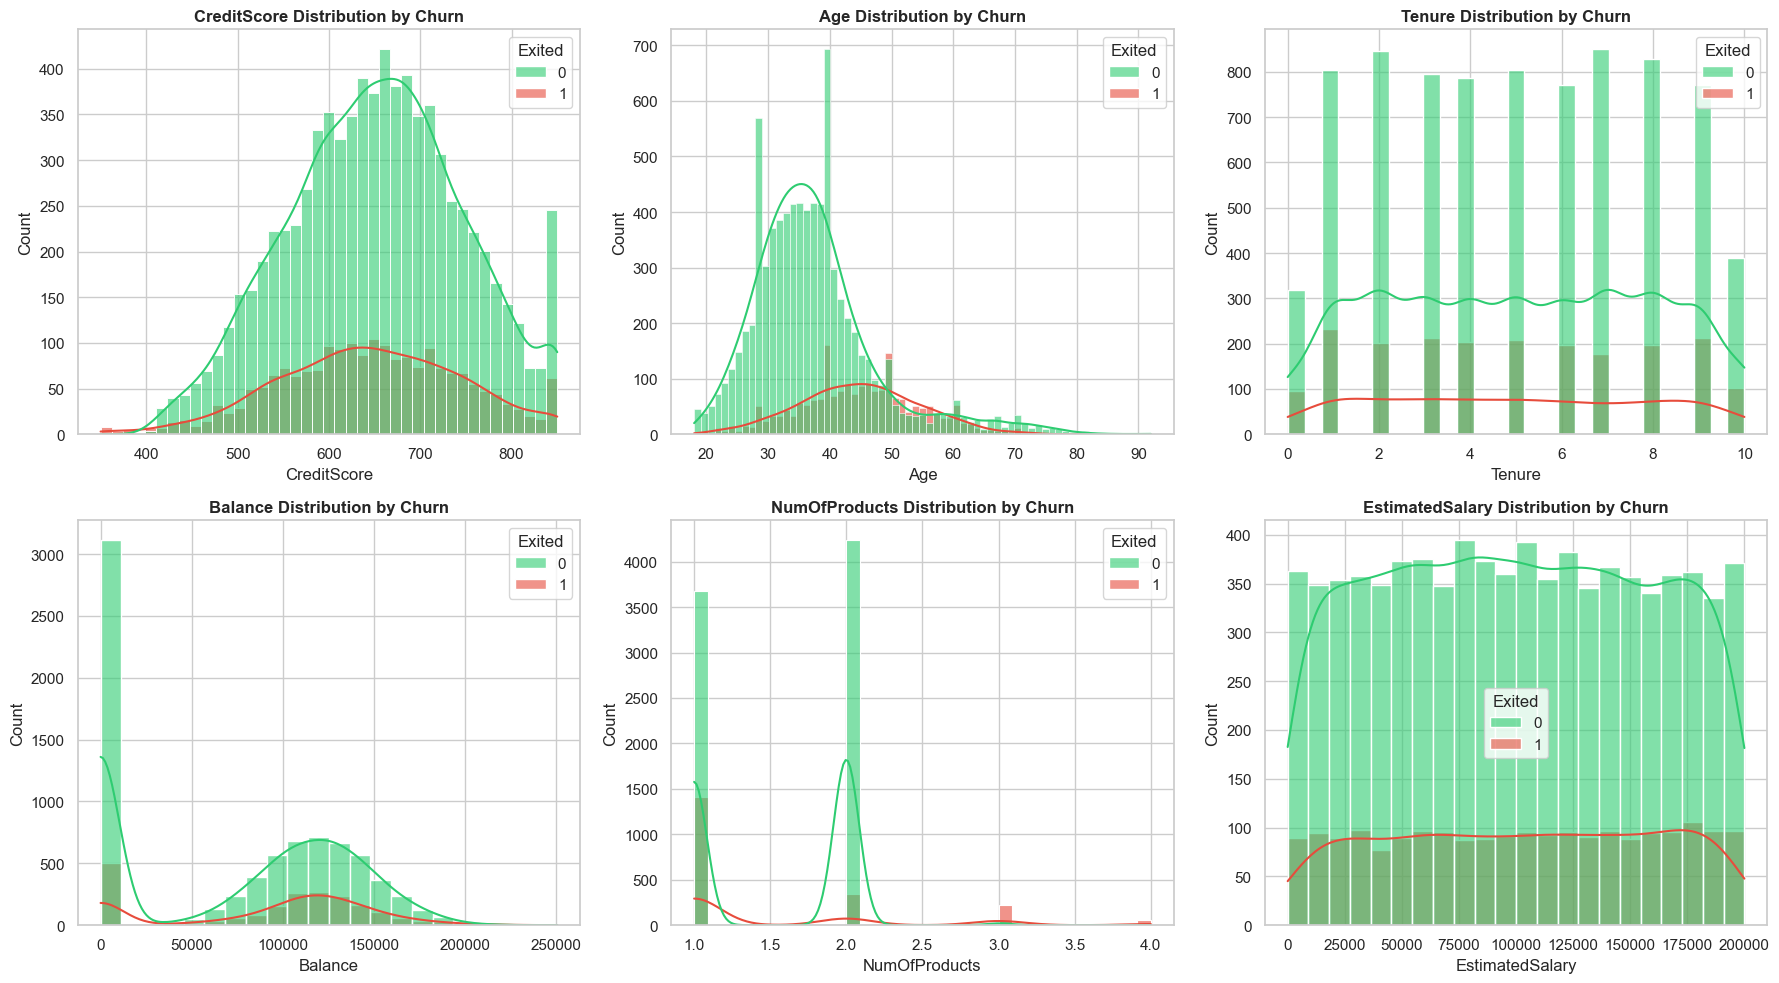

In [7]:
# Numerical feature distributions
num_features = ['CreditScore', 'Age', 'Tenure', 'Balance',
                'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(num_features):
    ax = axes[i // 3, i % 3]
    sns.histplot(data=df, x=col, hue=target_col, kde=True, ax=ax,
                 palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.6)
    ax.set_title(f'{col} Distribution by Churn', fontweight='bold')

plt.tight_layout()
plt.show()

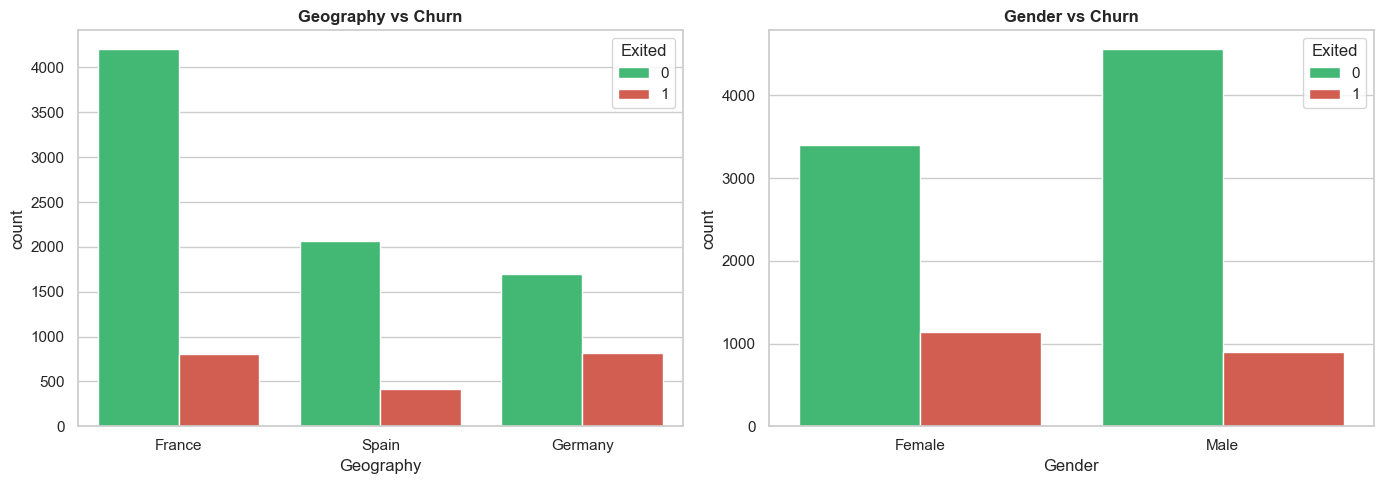

In [8]:
# Categorical feature distributions
cat_features = ['Geography', 'Gender']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, hue=target_col, ax=axes[i],
                  palette={0: '#2ecc71', 1: '#e74c3c'})
    axes[i].set_title(f'{col} vs Churn', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

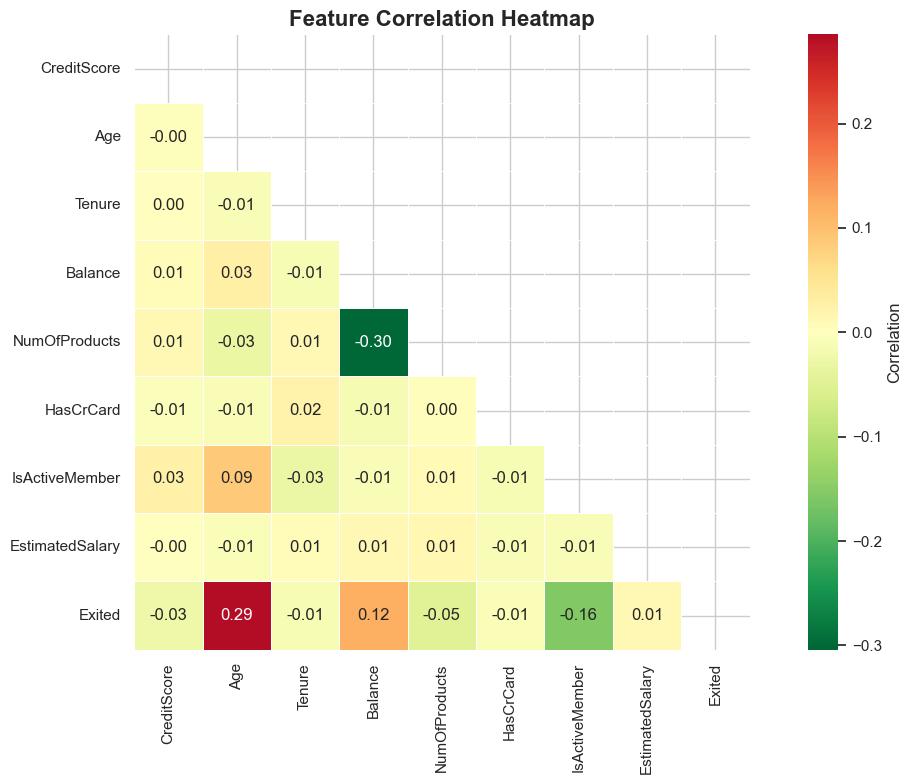

In [9]:
# Correlation matrix (numerical only)
corr_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
             'NumOfProducts', 'HasCrCard', 'IsActiveMember',
             'EstimatedSalary', 'Exited']

plt.figure(figsize=(12, 8))
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=0, linewidths=0.5,
            square=True, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [10]:
# Drop irrelevant columns
drop_cols = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=drop_cols)
print(f'Dropped columns: {drop_cols}')
print(f'Remaining columns: {list(df.columns)}')
df.head()

Dropped columns: ['RowNumber', 'CustomerId', 'Surname']
Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
# Encode categorical features with LabelEncoder
label_encoders = {}

for col in ['Geography', 'Gender']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print(f'\nLabel encoders saved for: {list(label_encoders.keys())}')
df.head()

Geography: {'France': np.int64(0), 'Germany': np.int64(1), 'Spain': np.int64(2)}
Gender: {'Female': np.int64(0), 'Male': np.int64(1)}

Label encoders saved for: ['Geography', 'Gender']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [12]:
# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

print(f'Feature matrix X: {X.shape}')
print(f'Target vector y: {y.shape}')
print(f'\nFeature names: {list(X.columns)}')

Feature matrix X: (10000, 10)
Target vector y: (10000,)

Feature names: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [13]:
# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set:     {X_test.shape[0]:,} samples')
print(f'\nTrain churn rate: {y_train.mean():.2%}')
print(f'Test churn rate:  {y_test.mean():.2%}')

Training set: 8,000 samples
Test set:     2,000 samples

Train churn rate: 20.38%
Test churn rate:  20.35%


In [14]:
# Feature scaling with StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Scaler fitted on training data.')
print(f'Scaled feature means (should be ~0): {X_train_scaled.mean(axis=0).round(4)}')

Scaler fitted on training data.
Scaled feature means (should be ~0): [-0. -0.  0.  0. -0.  0. -0.  0.  0. -0.]


## 5. Build ANN Model

In [15]:
n_features = X_train_scaled.shape[1]
print(f'Number of input features: {n_features}')

# Build ANN as per CLAUDE.md architecture convention
model = Sequential([
    Dense(64, activation='relu', input_shape=(n_features,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Number of input features: 10


C:\Users\Avengers\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape       ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ dense (Dense)            │ (None, 64)         │        704 │
├──────────────────────────┼────────────────────┼────────────┤
│ dropout (Dropout)        │ (None, 64)         │          0 │
├──────────────────────────┼────────────────────┼────────────┤
│ dense_1 (Dense)          │ (None, 32)         │      2,080 │
├──────────────────────────┼────────────────────┼────────────┤
│ dropout_1 (Dropout)      │ (None, 32)         │          0 │
├──────────────────────────┼────────────────────┼────────────┤
│ dense_2 (Dense)          │ (None, 1)          │         33 │
└──────────────────────────┴────────────────────┴────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model

In [16]:
# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7928 - loss: 0.4918 - val_accuracy: 0.8125 - val_loss: 0.4376
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8106 - loss: 0.4395 - val_accuracy: 0.8344 - val_loss: 0.4123
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8194 - loss: 0.4204 - val_accuracy: 0.8506 - val_loss: 0.3927
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8298 - loss: 0.4082 - val_accuracy: 0.8556 - val_loss: 0.3778
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8363 - loss: 0.3912 - val_accuracy: 0.8656 - val_loss: 0.3590
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8413 - loss: 0.3858 - val_accuracy: 0.8650 - val_loss: 0.3505
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8438 - loss: 0.3800 - val_accuracy: 0.8637 - val_loss: 0.3490
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8427 - loss: 0.3804 - val_accu

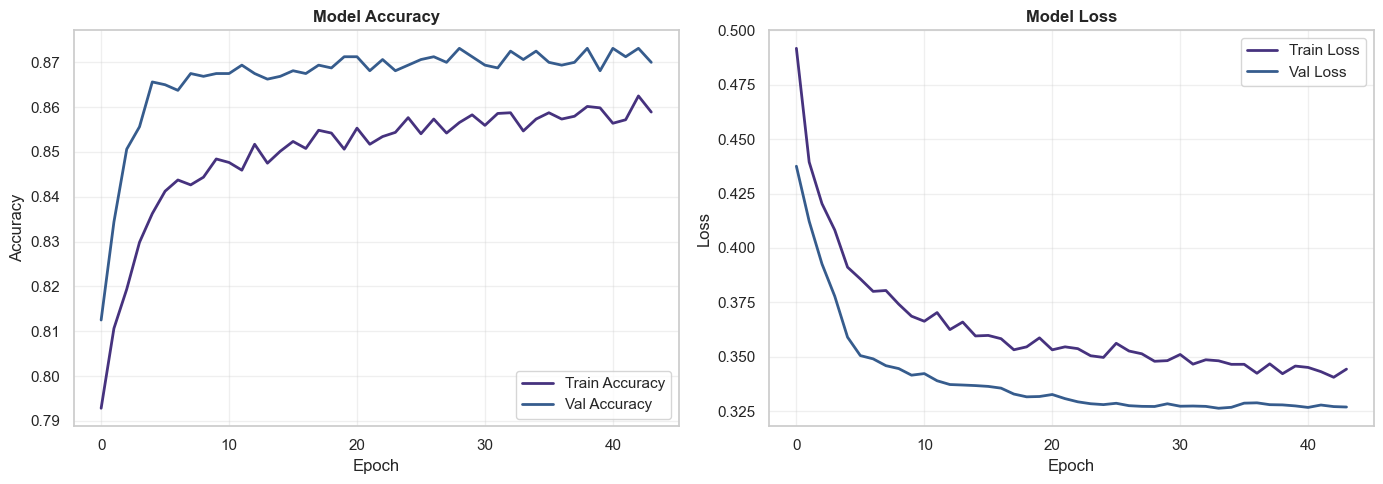

In [17]:
# Training history plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
ax1.set_title('Model Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
ax2.set_title('Model Loss', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Evaluate the Model

In [18]:
# Predictions
y_pred_prob = model.predict(X_test_scaled).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f'Test Accuracy: {accuracy:.4f} ({accuracy:.2%})')
print(f'ROC-AUC Score: {roc_auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test Accuracy: 0.8580 (85.80%)
ROC-AUC Score: 0.8531

Classification Report:
              precision    recall  f1-score   support

    Retained       0.87      0.97      0.92      1593
     Churned       0.77      0.43      0.55       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000



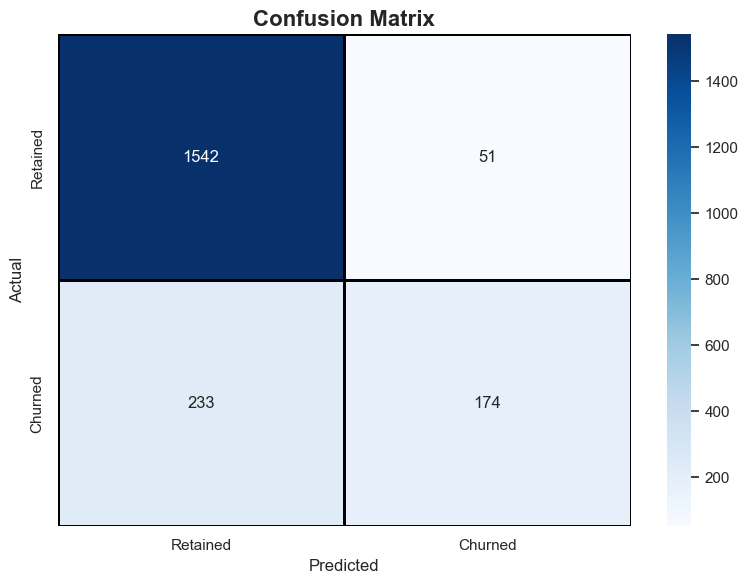

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'],
            linewidths=1, linecolor='black')
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

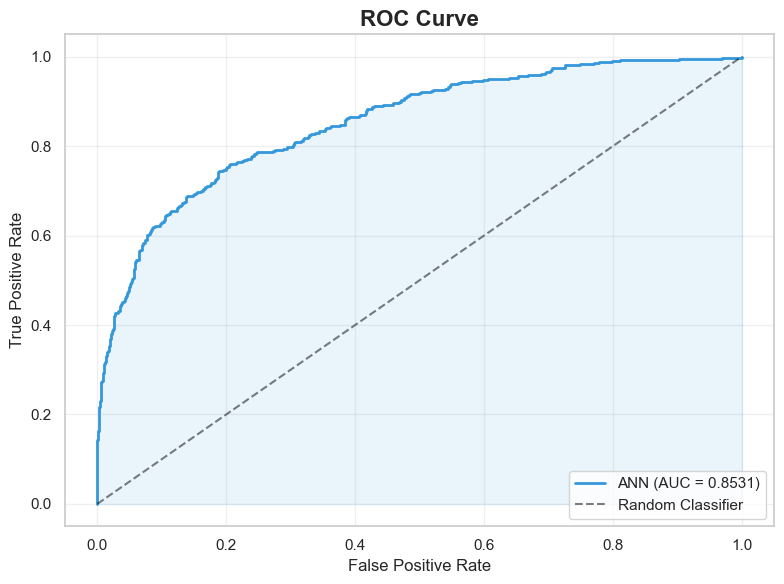

In [20]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#3498db', linewidth=2,
         label=f'ANN (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#3498db')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=16, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Save Model Artifacts

In [21]:
# Create models directory if it doesn't exist
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Save Keras model
model_path = os.path.join(models_dir, 'churn_model.h5')
model.save(model_path)
print(f'✅ Model saved to: {model_path}')

# Save StandardScaler
scaler_path = os.path.join(models_dir, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'✅ Scaler saved to: {scaler_path}')

# Save LabelEncoders
encoders_path = os.path.join(models_dir, 'label_encoders.pkl')
with open(encoders_path, 'wb') as f:
    pickle.dump(label_encoders, f)
print(f'✅ Label encoders saved to: {encoders_path}')

# Verify files
for fpath in [model_path, scaler_path, encoders_path]:
    size_mb = os.path.getsize(fpath) / (1024 * 1024)
    print(f'   {os.path.basename(fpath)}: {size_mb:.2f} MB')

✅ Model saved to: ../models\churn_model.h5
✅ Scaler saved to: ../models\scaler.pkl
✅ Label encoders saved to: ../models\label_encoders.pkl
   churn_model.h5: 0.06 MB
   scaler.pkl: 0.00 MB
   label_encoders.pkl: 0.00 MB


## 9. Quick Sanity Check — Predict a Sample

In [22]:
# Test prediction on a sample customer
sample = {
    'CreditScore': 600,
    'Geography': 0,     # France
    'Gender': 0,        # Female
    'Age': 40,
    'Tenure': 3,
    'Balance': 60000.0,
    'NumOfProducts': 2,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 50000.0
}

sample_df = pd.DataFrame([sample])
sample_scaled = scaler.transform(sample_df)
prob = model.predict(sample_scaled, verbose=0)[0][0]

print(f'Sample Customer Prediction:')
print(f'  Churn Probability: {prob:.4f} ({prob:.2%})')
print(f'  Prediction: {"Churn" if prob >= 0.5 else "Retained"}')
print(f'\n✅ Pipeline working end-to-end!')

Sample Customer Prediction:
  Churn Probability: 0.0859 (8.59%)
  Prediction: Retained

✅ Pipeline working end-to-end!


---

## ✅ Done!

Model artifacts saved in `../models/`:
- `churn_model.h5` — trained Keras ANN
- `scaler.pkl` — fitted StandardScaler
- `label_encoders.pkl` — fitted LabelEncoders

**Next steps:**
1. Start the backend: `cd backend && uvicorn main:app --reload --port 8000`
2. Start the frontend: `cd frontend && streamlit run app.py`
3. Open http://localhost:8501 to use the Churn Predictor UI